# Drosophila Brain Cocaine Response — Single-Cell RNA-Seq Analysis


## Step 0: Project root, imports, figure/results directories

In [1]:
from pathlib import Path

PROJECT_ROOT = Path(r"D:\bmp\sc_project2_drosophila_brain")
DATA_DIR = PROJECT_ROOT / "data"

RESULT_DIR = PROJECT_ROOT / "results"
FIG_DIR = RESULT_DIR / "figures"
TABLES_DIR = RESULT_DIR / "tables"

for d in (RESULT_DIR, FIG_DIR, TABLES_DIR):
    d.mkdir(parents=True, exist_ok=True)

assert DATA_DIR.exists(), f"data/ not found at {DATA_DIR} - check PROJECT_ROOT"

import sys
import gzip
import shutil
import gc
import math

import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=120, facecolor="white", frameon=False)
sc.settings.figdir = str(FIG_DIR)

print("Python:", sys.executable)
print("Project root:", PROJECT_ROOT.resolve())
print("Data dir:", DATA_DIR.resolve())
print("Figures dir:", FIG_DIR.resolve())
print("Results dir:", RESULT_DIR.resolve())
print("Tables dir:", TABLES_DIR.resolve())

Python: D:\bmp\sc_project2_drosophila_brain\.venv\Scripts\python.exe
Project root: D:\bmp\sc_project2_drosophila_brain
Data dir: D:\bmp\sc_project2_drosophila_brain\data
Figures dir: D:\bmp\sc_project2_drosophila_brain\results\figures
Results dir: D:\bmp\sc_project2_drosophila_brain\results
Tables dir: D:\bmp\sc_project2_drosophila_brain\results\tables


C:\Users\Acer\AppData\Local\Temp\ipykernel_12280\802298740.py:31: FutureWarning: The method set_figure_params is deprecated and will be removed in the future. Use :func:`scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=120, facecolor="white", frameon=False)


## Step 1: Fix `features.tsv.gz` files (space-delimited -> tab-delimited)
Idempotent — safe to rerun; skips files already fixed.

In [2]:
sample_dirs = sorted([
    p for p in DATA_DIR.iterdir()
    if p.is_dir() and (p / "matrix.mtx.gz").exists()
])
print(f"Found {len(sample_dirs)} samples: {[p.name for p in sample_dirs]}")

def features_needs_fix(path):
    with gzip.open(path, "rt") as f:
        first_line = f.readline()
    return "\t" not in first_line

def fix_features_file(path):
    backup = path.with_suffix(path.suffix + ".bak")
    if not backup.exists():
        shutil.copy(path, backup)

    with gzip.open(path, "rt") as f:
        lines = f.readlines()

    fixed_lines = []
    for line in lines:
        line = line.rstrip("\n")
        parts = line.split(" ", 2)  # gene_id, gene_symbol, feature_type ("Gene Expression")
        fixed_lines.append("\t".join(parts))

    with gzip.open(path, "wt") as f:
        f.write("\n".join(fixed_lines) + "\n")

for sample_path in sample_dirs:
    feat_file = sample_path / "features.tsv.gz"
    if features_needs_fix(feat_file):
        fix_features_file(feat_file)
        print(f"Fixed: {feat_file}")
    else:
        print(f"Already OK: {feat_file}")

Found 8 samples: ['Female_Cocaine_1', 'Female_Cocaine_2', 'Female_Sucrose_1', 'Female_Sucrose_2', 'Male_Cocaine_1', 'Male_Cocaine_2', 'Male_Sucrose_1', 'Male_Sucrose_2']
Already OK: D:\bmp\sc_project2_drosophila_brain\data\Female_Cocaine_1\features.tsv.gz
Already OK: D:\bmp\sc_project2_drosophila_brain\data\Female_Cocaine_2\features.tsv.gz
Already OK: D:\bmp\sc_project2_drosophila_brain\data\Female_Sucrose_1\features.tsv.gz
Already OK: D:\bmp\sc_project2_drosophila_brain\data\Female_Sucrose_2\features.tsv.gz
Already OK: D:\bmp\sc_project2_drosophila_brain\data\Male_Cocaine_1\features.tsv.gz
Already OK: D:\bmp\sc_project2_drosophila_brain\data\Male_Cocaine_2\features.tsv.gz
Already OK: D:\bmp\sc_project2_drosophila_brain\data\Male_Sucrose_1\features.tsv.gz
Already OK: D:\bmp\sc_project2_drosophila_brain\data\Male_Sucrose_2\features.tsv.gz


## Step 2: Load all 8 samples into one AnnData object

In [3]:
adatas = {}
for sample_path in sample_dirs:
    sample_name = sample_path.name
    adata_sample = sc.read_10x_mtx(
        path=sample_path, var_names="gene_symbols", cache=False
    )
    parts = sample_name.split("_")  # e.g. "Female_Cocaine_1"
    sex, treatment, replicate = parts[0], parts[1], parts[2]

    adata_sample.obs["sample"] = sample_name
    adata_sample.obs["sex"] = sex
    adata_sample.obs["treatment"] = treatment
    adata_sample.obs["replicate"] = replicate
    adata_sample.obs["condition"] = f"{sex}_{treatment}"

    adatas[sample_name] = adata_sample

adata = ad.concat(adatas, label="sample_batch", index_unique="-", join="outer")
adata.var_names_make_unique()

print(f"Merged Dataset: {adata.n_obs} cells x {adata.n_vars} genes")

--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
Merged Dataset: 88991 cells x 17481 genes


## Step 3: QC metrics & visualization

C:\Users\Acer\AppData\Local\Temp\ipykernel_12280\2998829470.py:6: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.violin(


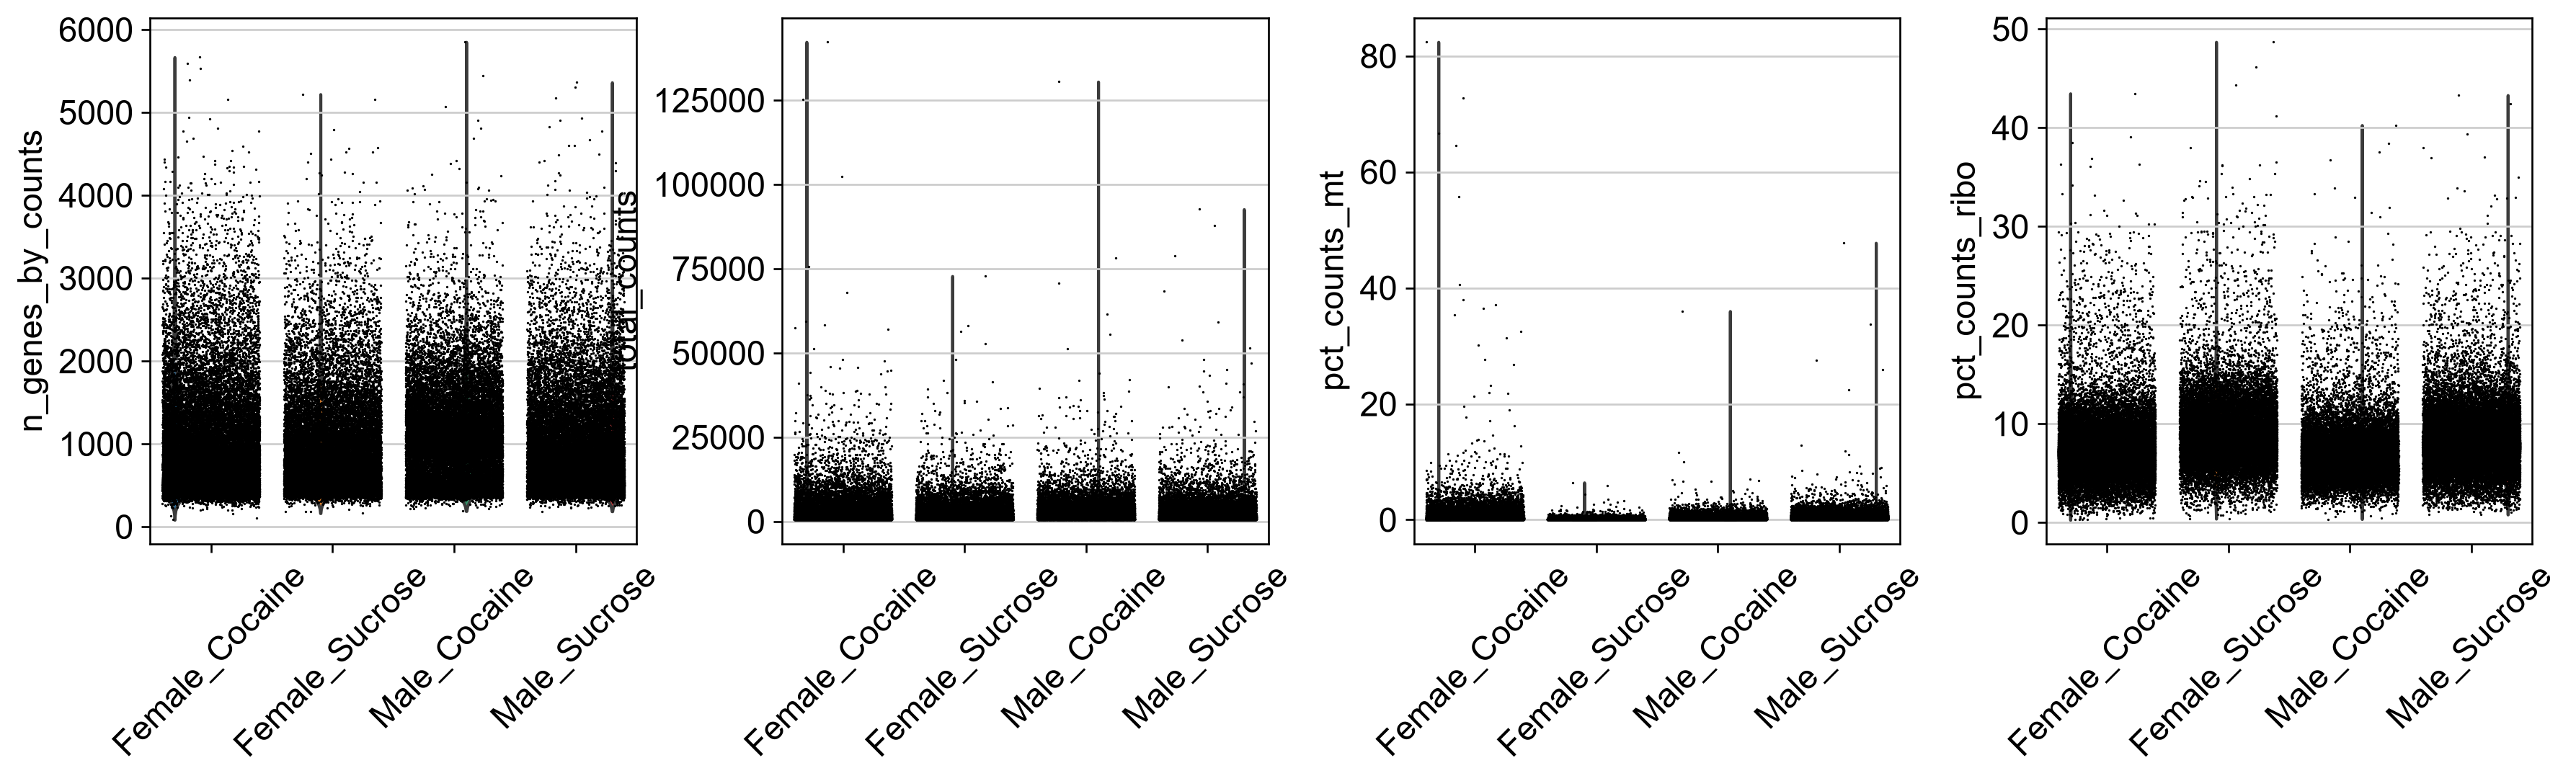

In [4]:
adata.var["mt"] = adata.var_names.str.startswith("mt:")
adata.var["ribo"] = adata.var_names.str.startswith(("RpS", "RpL", "rps", "rpl"))

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo"], inplace=True)

sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"],
    groupby="condition",
    jitter=0.4,
    rotation=45,
    multi_panel=True,
    save="_QC_violin.png"
)

## Step 4: Filter cells & genes

In [5]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs["pct_counts_mt"] < 10.0, :].copy()

print(f"Cells remaining after QC: {adata.n_obs}")

filtered out 11 cells that have less than 200 genes expressed
filtered out 4340 genes that are detected in less than 3 cells
Cells remaining after QC: 88923


## Step 5: Drop genes with missing/invalid names

In [6]:
valid_genes = adata.var_names.notna() & (adata.var_names != "")
print(f"Dropping {(~valid_genes).sum()} genes with missing/invalid names")

adata = adata[:, valid_genes].copy()
adata.var_names_make_unique()

print(f"Genes remaining: {adata.n_vars}")

Dropping 1 genes with missing/invalid names
Genes remaining: 13140


## Step 6: Stratified subsample (documented memory-constraint limitation)


In [7]:
target_per_sample = 4000  # lower this if the memory wall is hit again

print(adata.obs["sample"].value_counts())

sampled_idx = []
for sample_name, group in adata.obs.groupby("sample"):
    n = min(target_per_sample, len(group))
    sampled_idx.extend(group.sample(n=n, random_state=RANDOM_STATE).index)

adata = adata[sampled_idx].copy()

for col in ["sample", "sex", "treatment", "replicate", "condition"]:
    if hasattr(adata.obs[col], "cat"):
        adata.obs[col] = adata.obs[col].cat.remove_unused_categories()

print(f"Subsampled dataset: {adata.n_obs} cells x {adata.n_vars} genes")
print(adata.obs["sample"].value_counts())

sample
Male_Sucrose_1      13191
Female_Cocaine_1    13072
Female_Sucrose_2    11693
Male_Cocaine_2      11124
Male_Sucrose_2      11027
Male_Cocaine_1      10433
Female_Cocaine_2     9315
Female_Sucrose_1     9068
Name: count, dtype: int64
Subsampled dataset: 32000 cells x 13140 genes
sample
Female_Cocaine_1    4000
Female_Cocaine_2    4000
Female_Sucrose_1    4000
Female_Sucrose_2    4000
Male_Cocaine_1      4000
Male_Cocaine_2      4000
Male_Sucrose_1      4000
Male_Sucrose_2      4000
Name: count, dtype: int64


## Step 7: Normalize, log-transform, select highly variable genes

normalizing counts per cell
    finished (0:00:07)
extracting highly variable genes
    finished (0:00:07)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


C:\Users\Acer\AppData\Local\Temp\ipykernel_12280\602732978.py:8: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.highly_variable_genes(adata, save="_HVG.png")


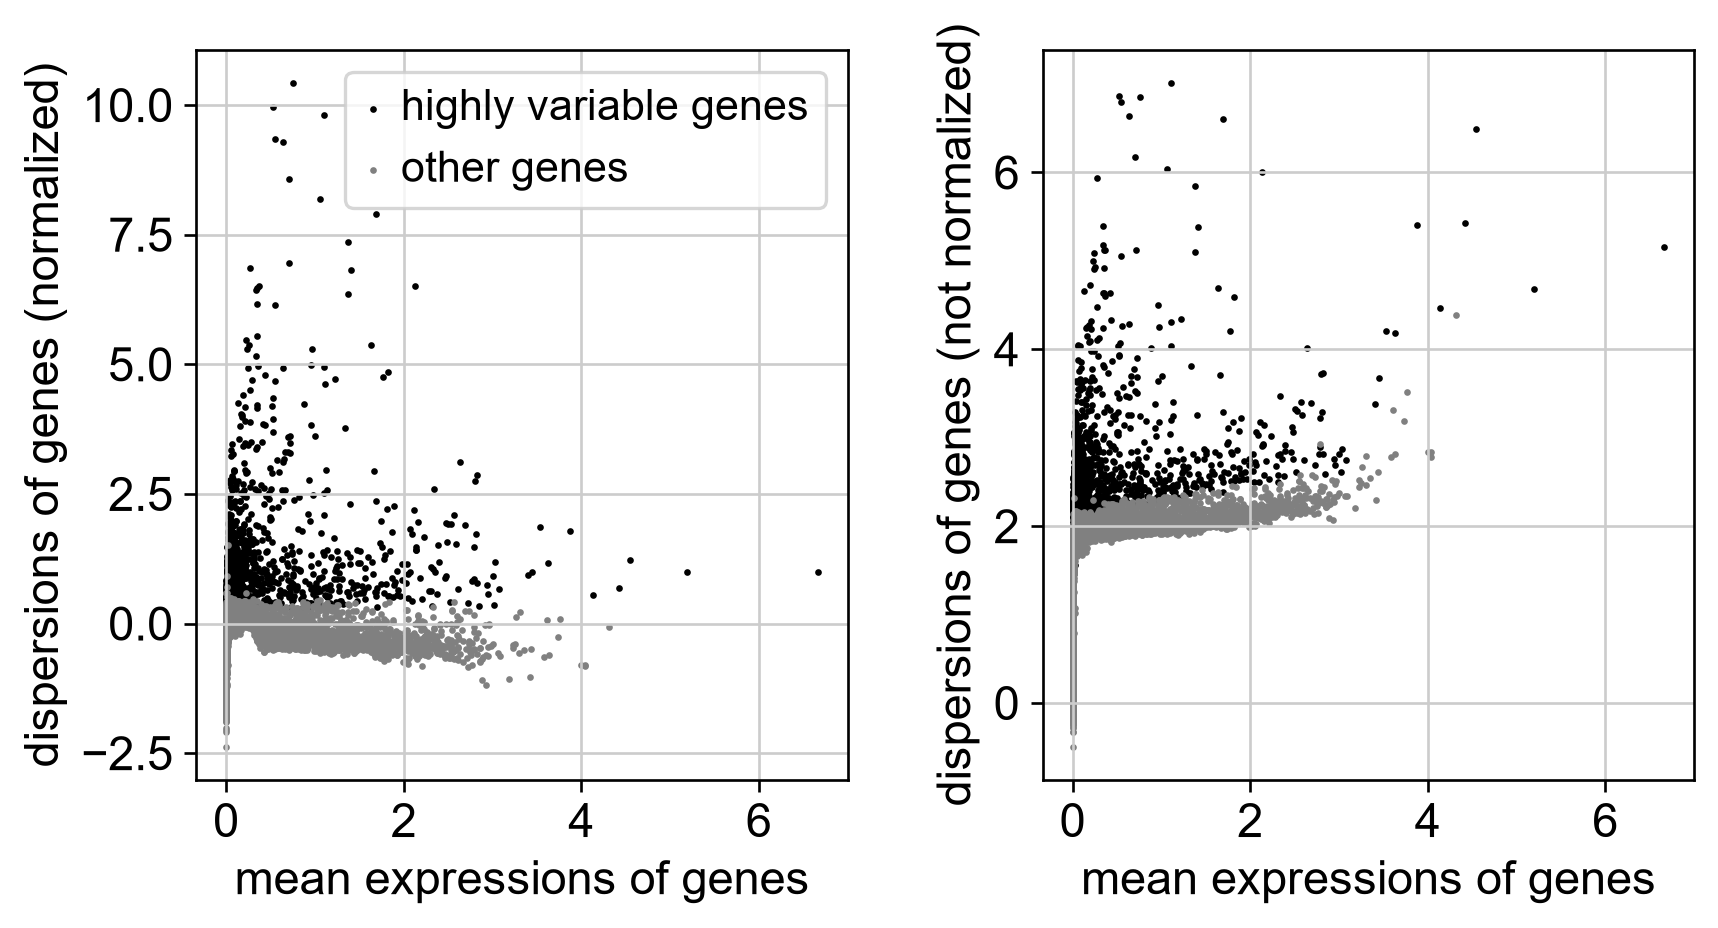

2000 HVGs selected


In [8]:
adata.X = adata.X.astype("float32")

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata  # full-gene, log-normalized data kept for later marker/DE lookups

sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample")
sc.pl.highly_variable_genes(adata, save="_HVG.png")

assert "highly_variable" in adata.var.columns
print(f"{adata.var['highly_variable'].sum()} HVGs selected")

## Step 8: Subset to HVGs, scale, PCA

Subset to HVGs: 32000 cells x 2000 genes


C:\Users\Acer\AppData\Local\Python\pythoncore-3.14-64\Lib\functools.py:982: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA
    with n_comps=30


C:\Users\Acer\AppData\Local\Temp\ipykernel_12280\2009883524.py:9: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.tl.pca(adata, n_comps=30, svd_solver="arpack", use_highly_variable=True, random_state=RANDOM_STATE)


    finished (0:00:06)


C:\Users\Acer\AppData\Local\Temp\ipykernel_12280\2009883524.py:10: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca_variance_ratio(adata, log=True, n_pcs=30, save="_PCA_variance.png")


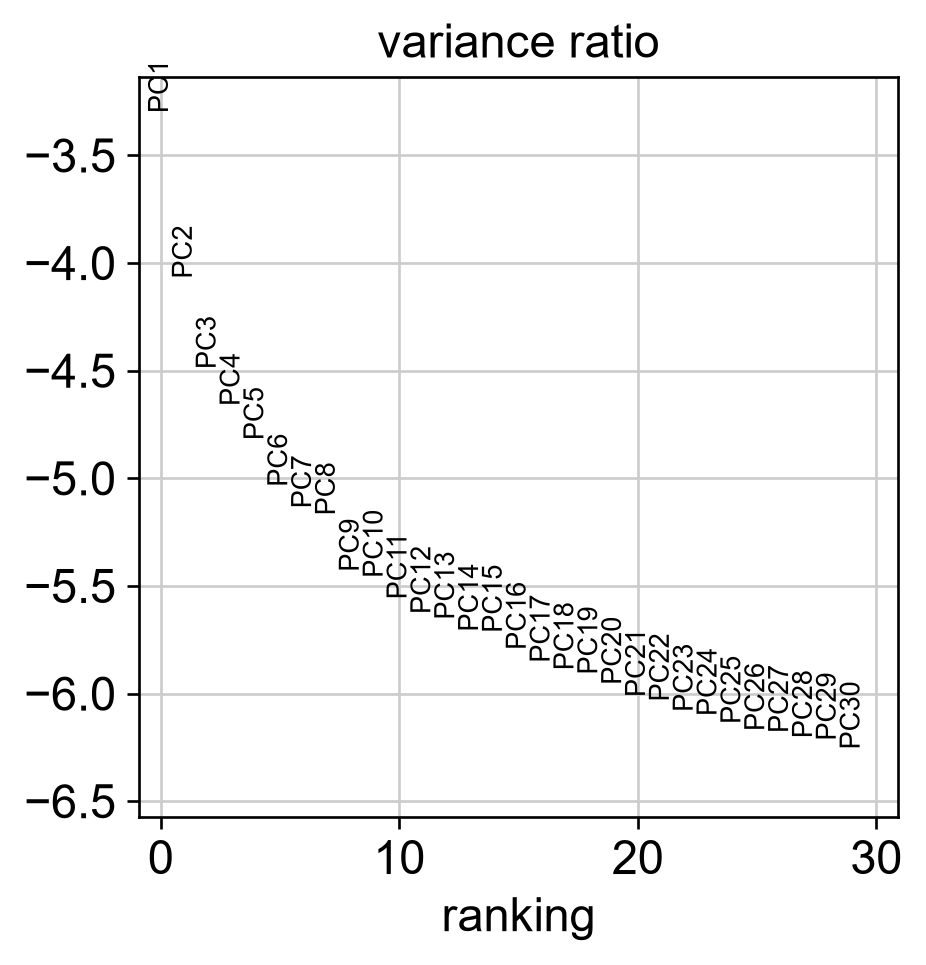

In [9]:
adata = adata[:, adata.var["highly_variable"]].copy()
gc.collect()
print(f"Subset to HVGs: {adata.n_obs} cells x {adata.n_vars} genes")

sc.pp.scale(adata, max_value=10)
adata.X = adata.X.astype("float32")
gc.collect()

sc.tl.pca(adata, n_comps=30, svd_solver="arpack", use_highly_variable=True, random_state=RANDOM_STATE)
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=30, save="_PCA_variance.png")

## Step 9: Neighbors, UMAP, Leiden clustering (target ~36 clusters)
Run as separate cells so a crash pinpoints exactly which step failed.

In [10]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30, random_state=RANDOM_STATE)
gc.collect()

computing neighbors
    using 'X_pca' with n_pcs = 30
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:01:32)


59202

In [11]:
sc.tl.umap(adata, random_state=RANDOM_STATE)
gc.collect()

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:31)


26214

C:\Users\Acer\AppData\Local\Temp\ipykernel_12280\2967568578.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.8, key_added="leiden_res_0.8", random_state=RANDOM_STATE)


running Leiden clustering
    finished: found 23 clusters and added
    'leiden_res_0.8', the cluster labels (adata.obs, categorical) (0:00:46)
Identified 23 clusters (Target: ~36; teammate's full-data run: 28).


C:\Users\Acer\AppData\Local\Temp\ipykernel_12280\2967568578.py:6: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


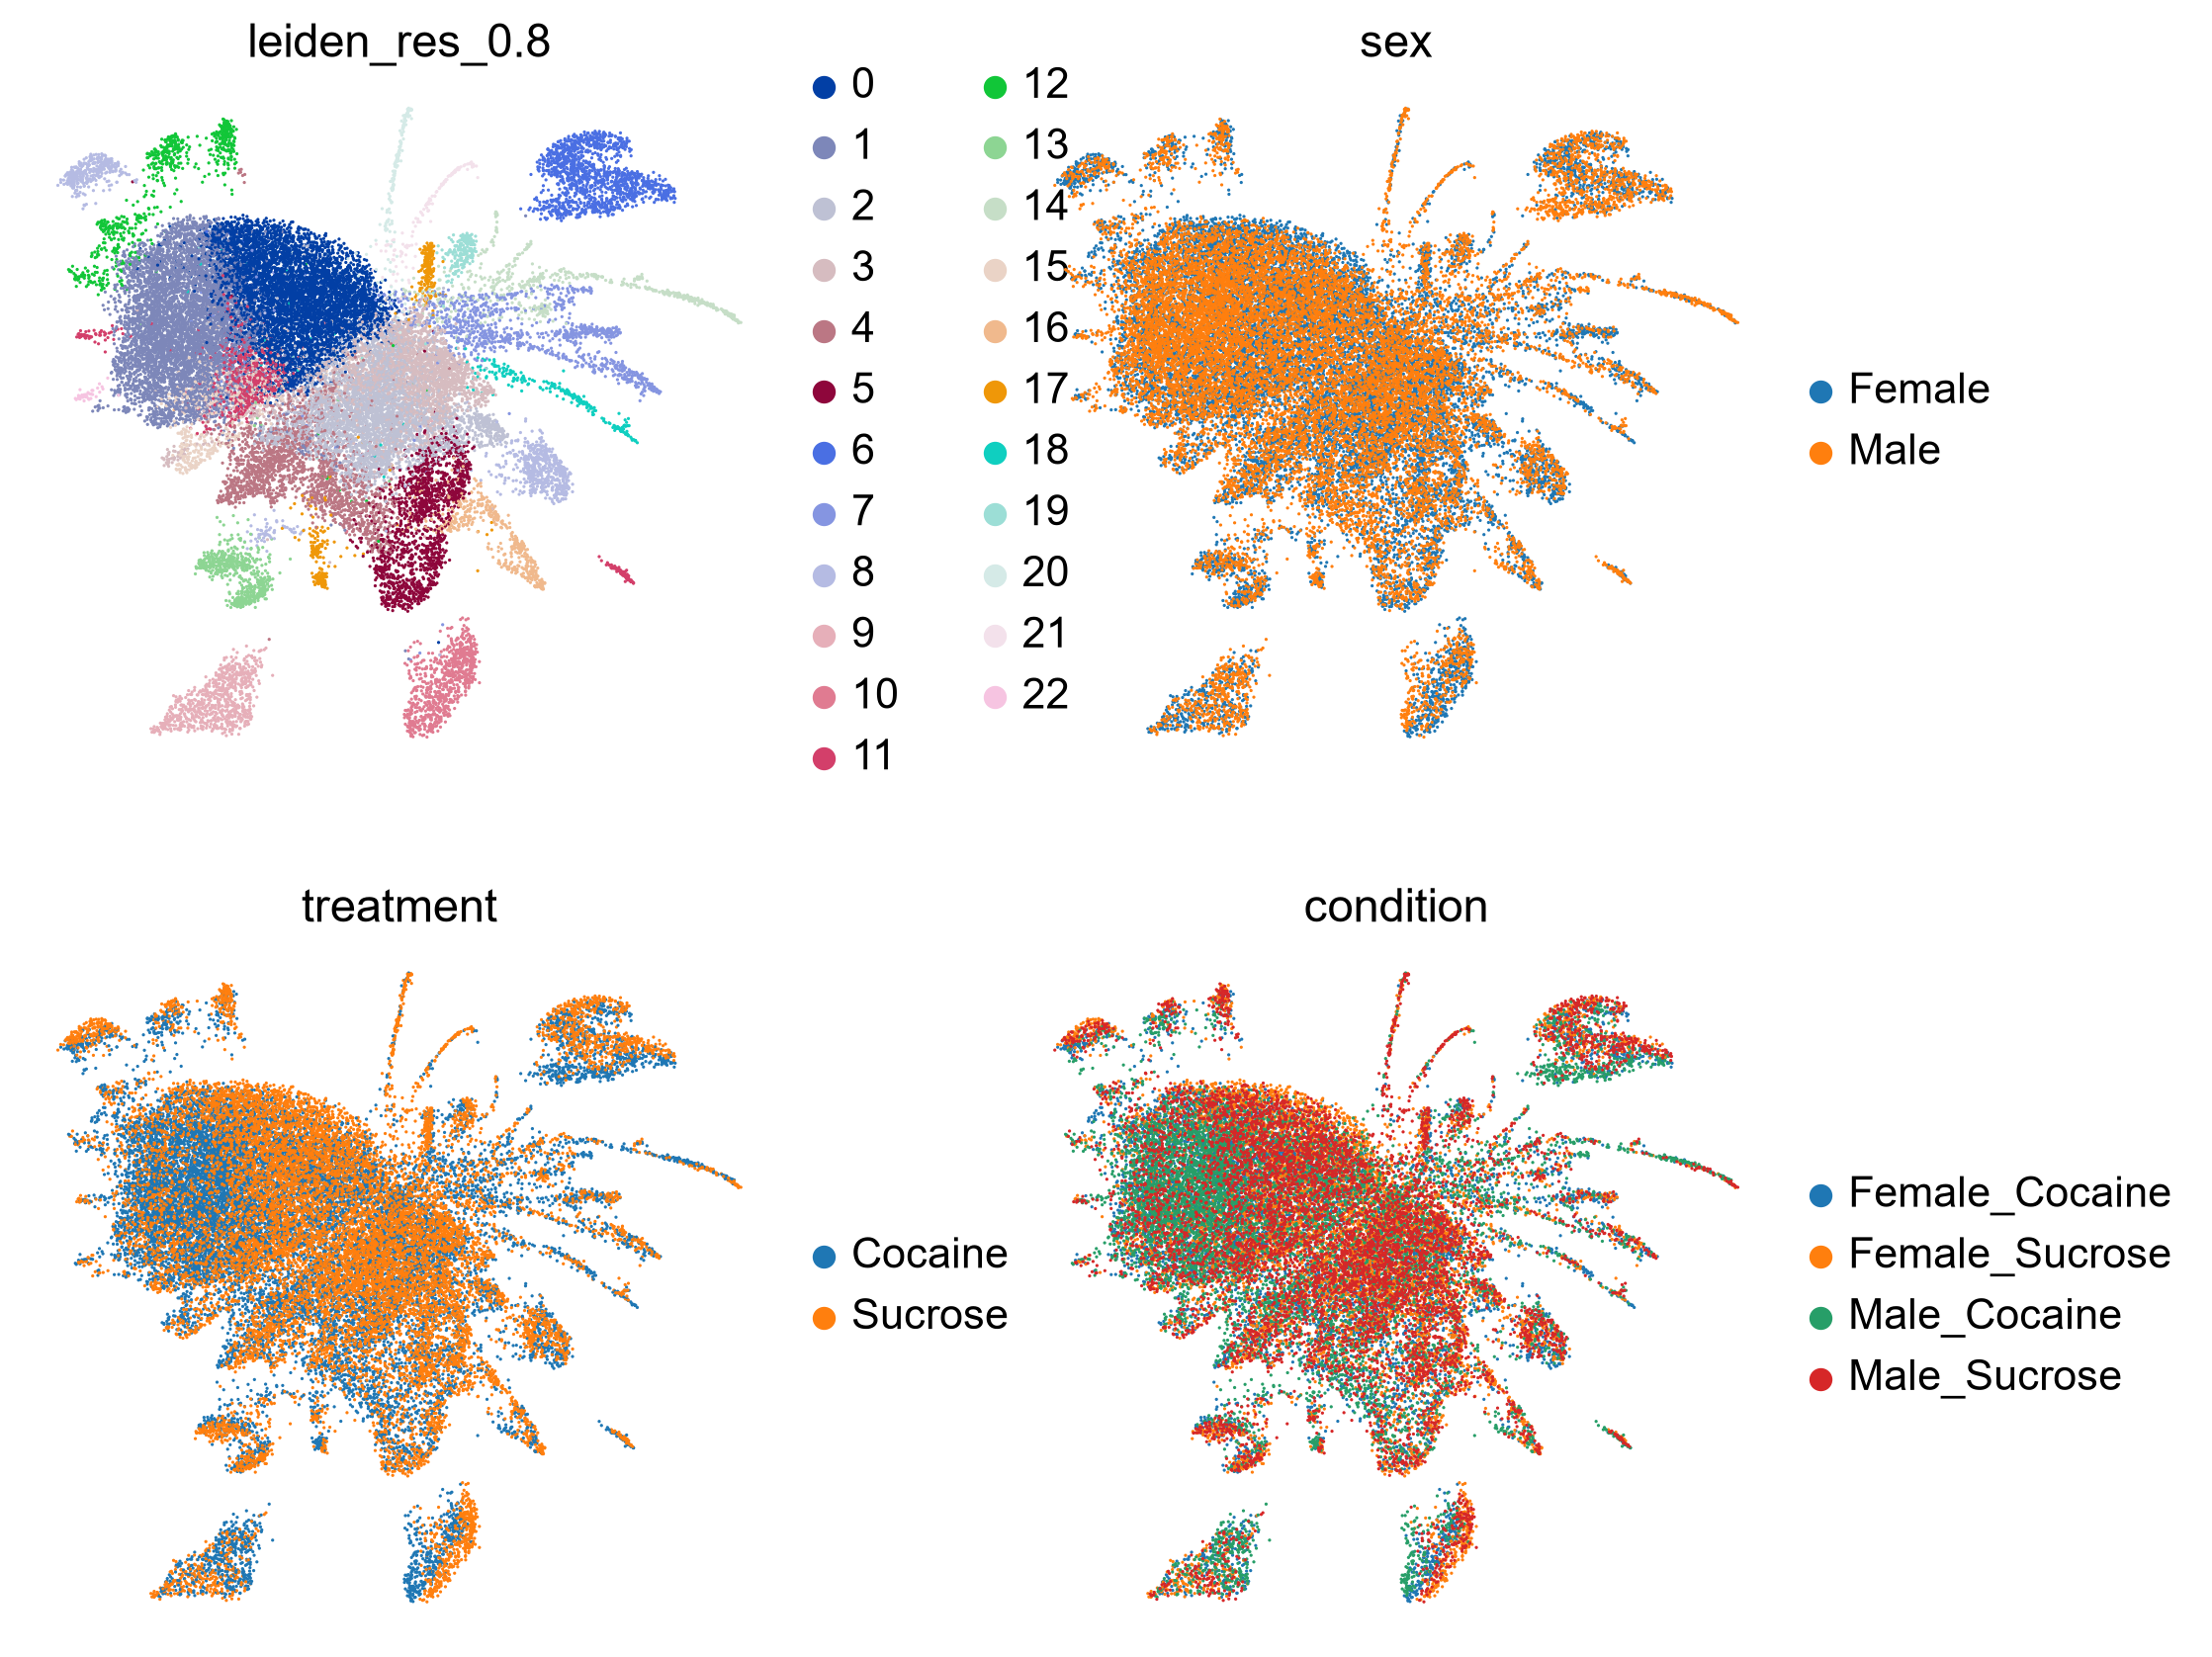

In [12]:
sc.tl.leiden(adata, resolution=0.8, key_added="leiden_res_0.8", random_state=RANDOM_STATE)

num_clusters = len(adata.obs["leiden_res_0.8"].unique())
print(f"Identified {num_clusters} clusters (Target: ~36; teammate's full-data run: 28).")

sc.pl.umap(
    adata, color=["leiden_res_0.8", "sex", "treatment", "condition"], ncols=2,
    save="_clusters_metadata.png",
)

## Step 10: Cluster annotation with canonical neurotransmitter markers

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:01:01)
Available markers: ['repo', 'ey', 'Fas2', 'VAChT', 'Gad1', 'ple', 'SerT', 'Tdc2']
Missing markers (not in HVG set): ['elav', 'VGlut']


C:\Users\Acer\AppData\Local\Temp\ipykernel_12280\2683044638.py:12: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.dotplot(


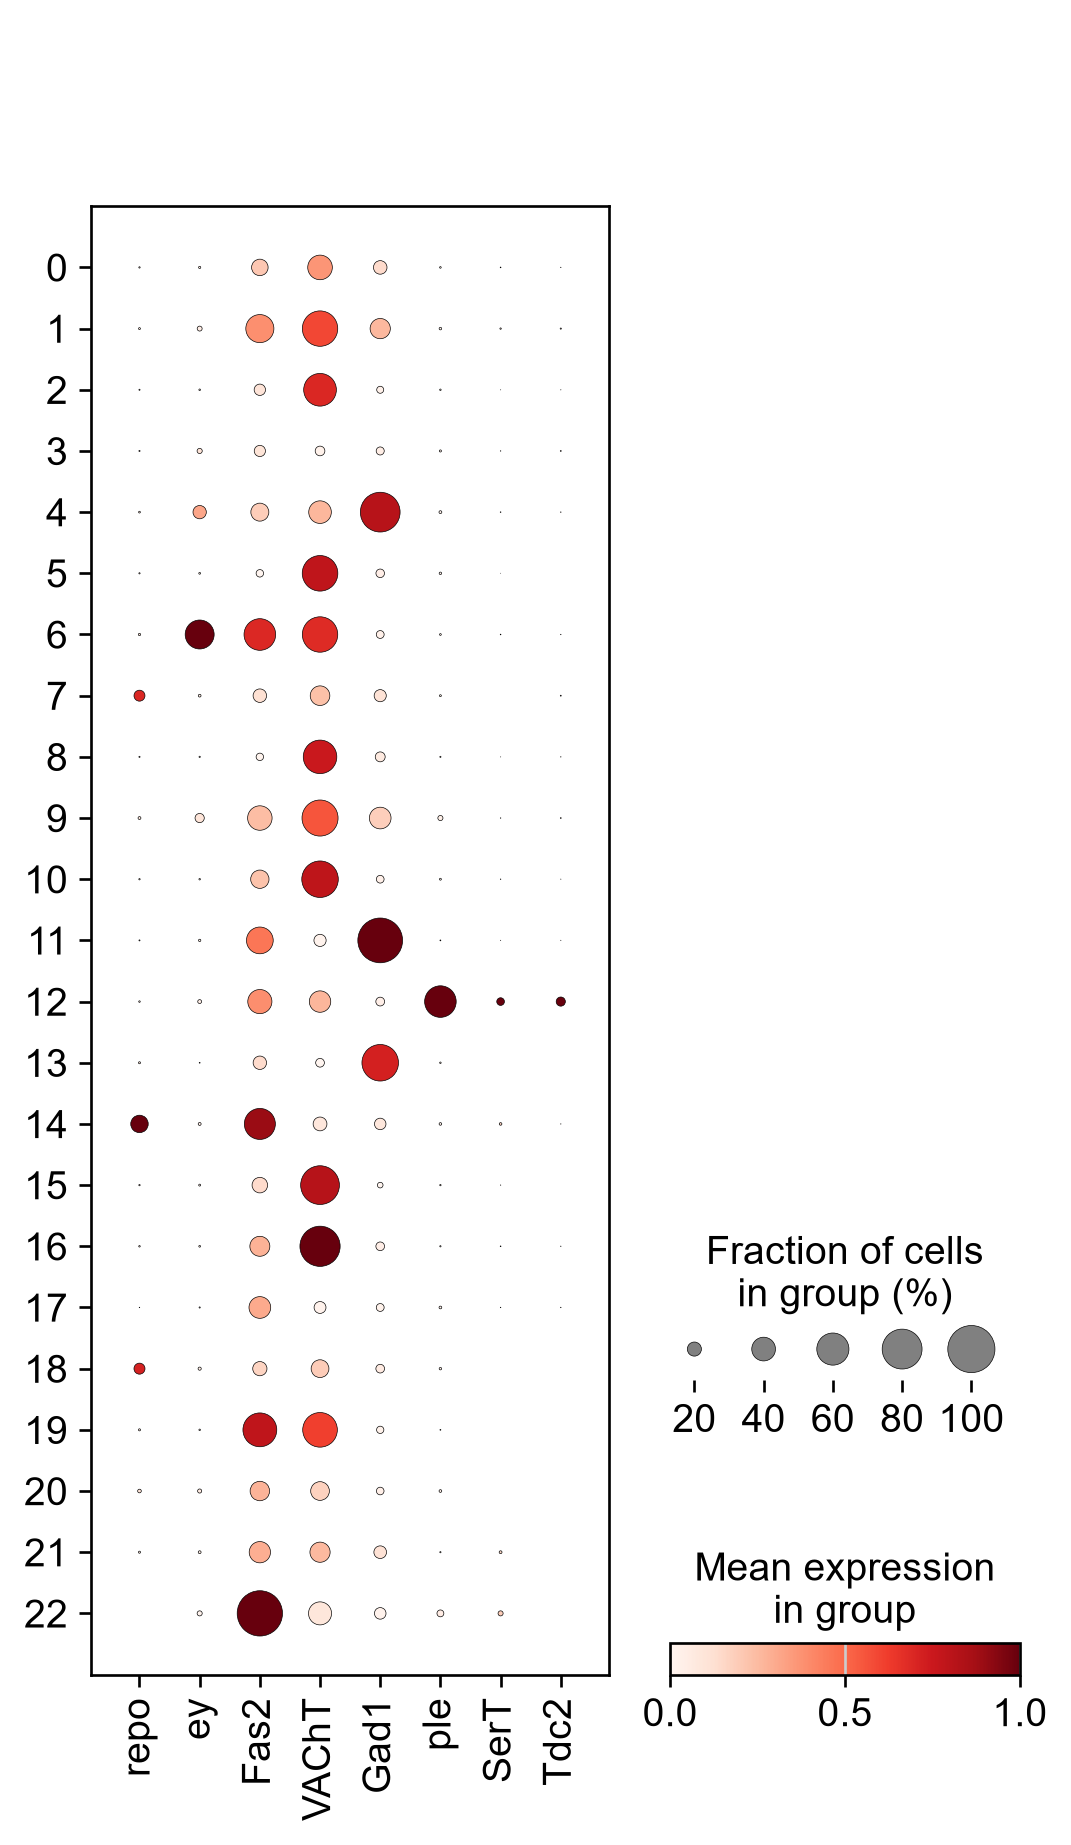

In [13]:
sc.tl.rank_genes_groups(adata, groupby="leiden_res_0.8", method="wilcoxon")
cluster_markers = sc.get.rank_genes_groups_df(adata, group=None)
cluster_markers.to_csv(TABLES_DIR / "cluster_markers_wilcoxon.csv", index=False)

canonical_markers = ["repo", "elav", "ey", "Fas2", "VAChT", "Gad1", "VGlut", "ple", "SerT", "Tdc2"]
available_markers = [g for g in canonical_markers if g in adata.var_names]
missing_markers = [g for g in canonical_markers if g not in adata.var_names]
print("Available markers:", available_markers)
print("Missing markers (not in HVG set):", missing_markers)

if available_markers:
    sc.pl.dotplot(
        adata, var_names=available_markers, groupby="leiden_res_0.8",
        standard_scale="var", save="_canonical_markers.png",
    )

### Note on markers not in the HVG set
A missing marker can still be visualized via the full gene set in `adata.raw`:
```python
sc.pl.umap(adata, color=['ple'], use_raw=True)
```

## Step 11: Differential expression — Cocaine vs. Sucrose, by sex
Publication threshold: |log2FC| > 1.0 and adjusted p < 0.05. Keeps both the full (`_de`) and significant-only (`_sig`) tables — the full tables are needed for the volcano plots in Step 13.

In [14]:
def sex_specific_de(adata_all, sex_name):
    subset = adata_all[adata_all.obs["sex"].astype(str) == sex_name].copy()
    sc.tl.rank_genes_groups(subset, groupby="treatment", reference="Sucrose", method="wilcoxon")
    de = sc.get.rank_genes_groups_df(subset, group="Cocaine")
    de["significant"] = de["logfoldchanges"].abs().gt(1.0) & de["pvals_adj"].lt(0.05)
    return subset, de

adata_male, male_de = sex_specific_de(adata, "Male")
adata_female, female_de = sex_specific_de(adata, "Female")

male_sig = male_de[male_de["significant"]].copy()
female_sig = female_de[female_de["significant"]].copy()

print("Male significant genes:", len(male_sig))
print("Female significant genes:", len(female_sig))

male_de.to_csv(TABLES_DIR / "male_Cocaine_vs_Sucrose_all_DE.csv", index=False)
female_de.to_csv(TABLES_DIR / "female_Cocaine_vs_Sucrose_all_DE.csv", index=False)
male_sig.to_csv(TABLES_DIR / "male_Cocaine_vs_Sucrose_significant_DE.csv", index=False)
female_sig.to_csv(TABLES_DIR / "female_Cocaine_vs_Sucrose_significant_DE.csv", index=False)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:29)
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:30)
Male significant genes: 70
Female significant genes: 156


## Step 12: Male/female DE overlap (sexual dimorphism check)

In [15]:
male_genes = set(male_sig["names"].astype(str))
female_genes = set(female_sig["names"].astype(str))
shared_genes = sorted(male_genes & female_genes)
male_only = sorted(male_genes - female_genes)
female_only = sorted(female_genes - male_genes)

overlap = pd.DataFrame({
    "category": ["Male-only", "Female-only", "Shared"],
    "n_genes": [len(male_only), len(female_only), len(shared_genes)],
})
display(overlap)

pd.DataFrame({"gene": shared_genes}).to_csv(TABLES_DIR / "shared_DE_genes.csv", index=False)
pd.DataFrame({"gene": male_only}).to_csv(TABLES_DIR / "male_only_DE_genes.csv", index=False)
pd.DataFrame({"gene": female_only}).to_csv(TABLES_DIR / "female_only_DE_genes.csv", index=False)

,category,n_genes
0,Male-only,46
1,Female-only,132
2,Shared,24


## Step 13: Volcano plots (Figure 4)

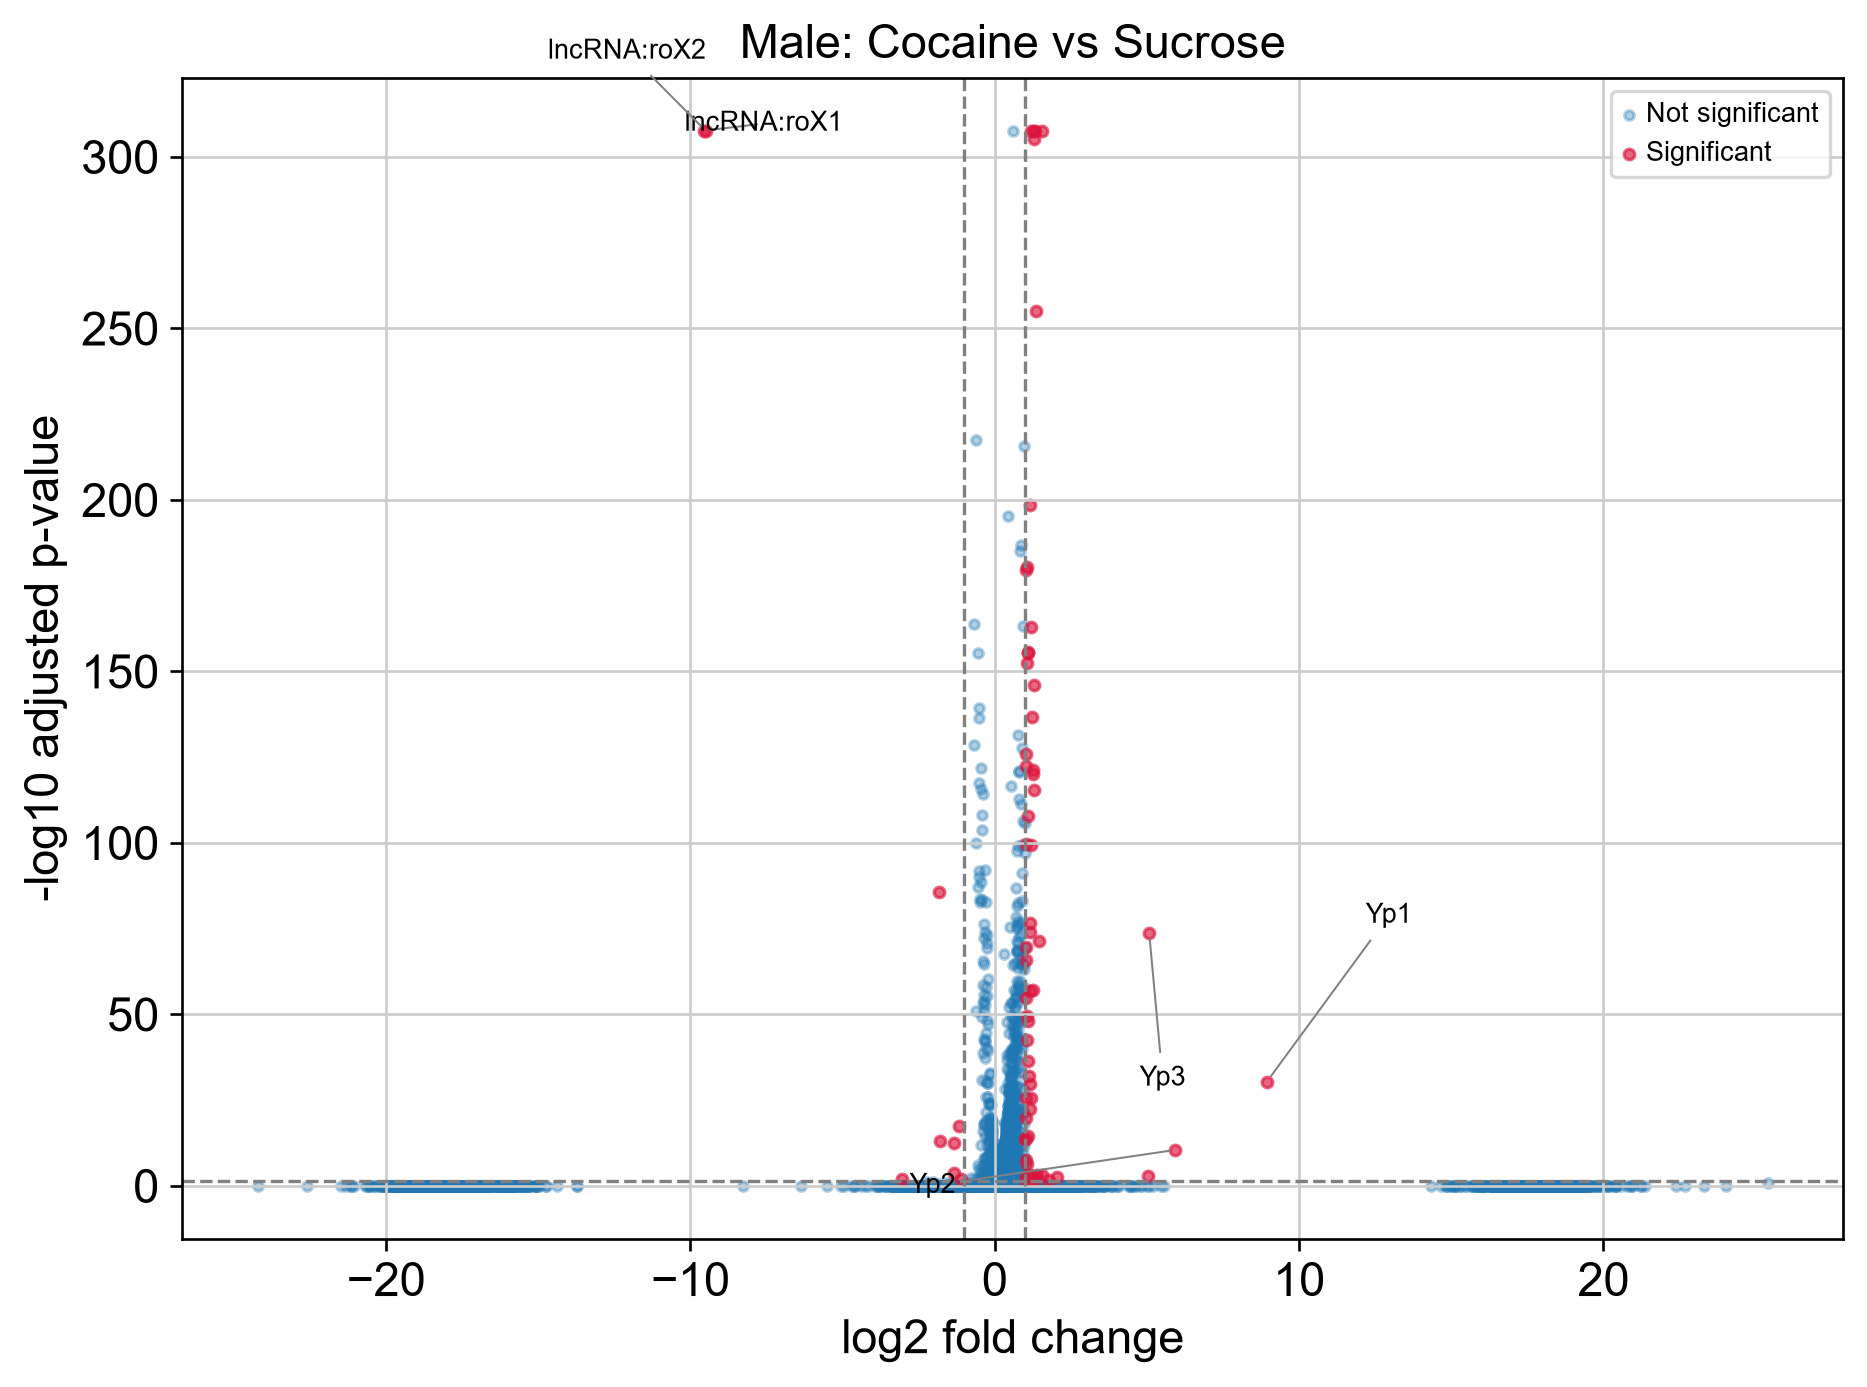

Saved: D:\bmp\sc_project2_drosophila_brain\results\figures\male_volcano.png


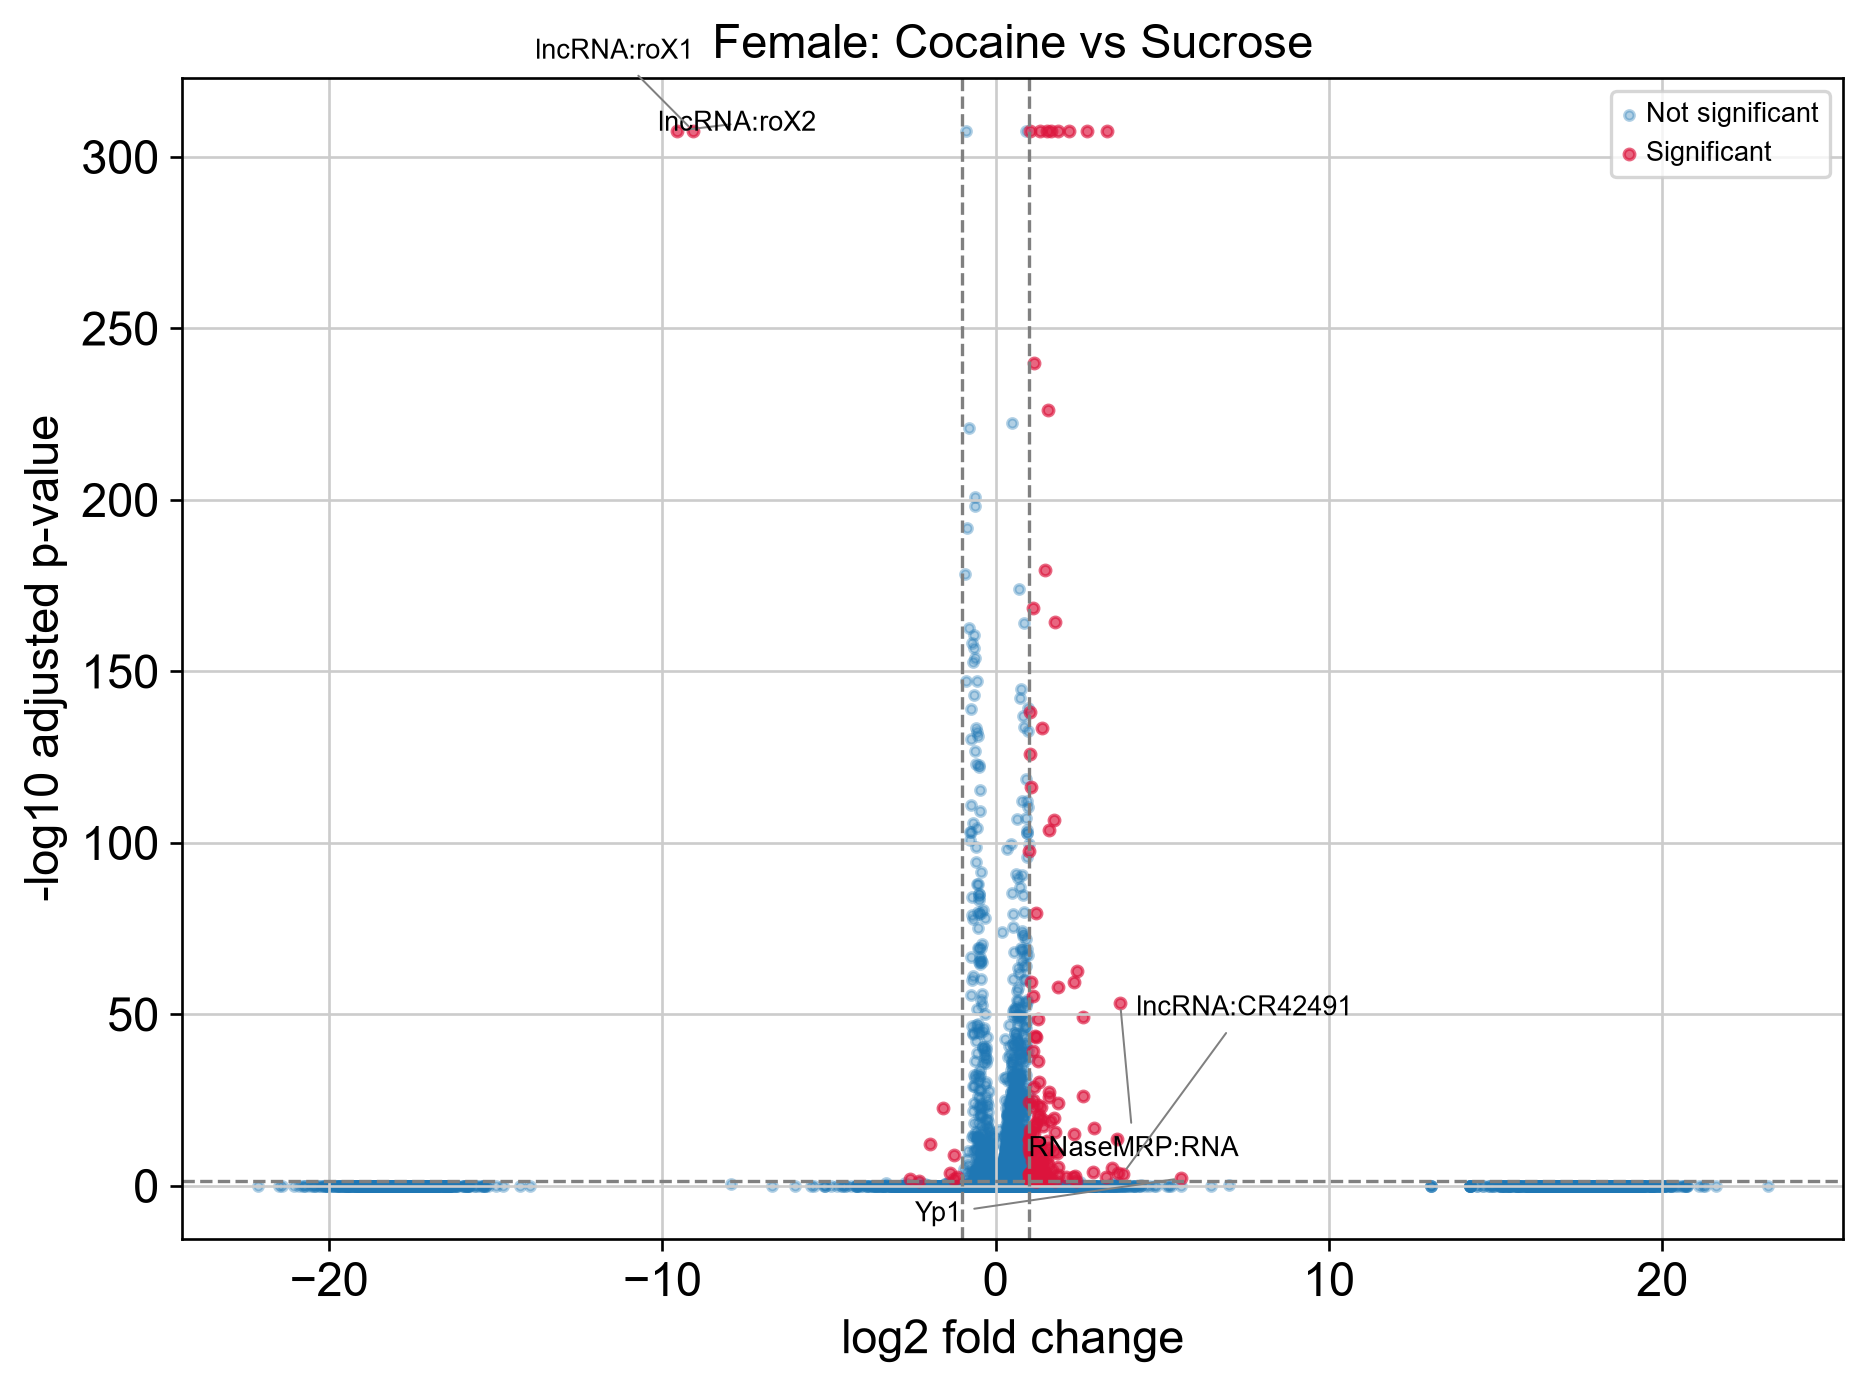

Saved: D:\bmp\sc_project2_drosophila_brain\results\figures\female_volcano.png


In [16]:
def volcano(de, title, filename, label_top_n=5):
    df = de.copy()
    df["neglog10_padj"] = -np.log10(df["pvals_adj"].clip(lower=np.finfo(float).tiny))
    sig = df["logfoldchanges"].abs().gt(1) & df["pvals_adj"].lt(0.05)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(df.loc[~sig, "logfoldchanges"], df.loc[~sig, "neglog10_padj"], s=8, alpha=0.35, label="Not significant")
    ax.scatter(df.loc[sig, "logfoldchanges"], df.loc[sig, "neglog10_padj"], s=10, alpha=0.65, color="crimson", label="Significant")
    ax.axvline(1, ls="--", lw=1, color="gray")
    ax.axvline(-1, ls="--", lw=1, color="gray")
    ax.axhline(-np.log10(0.05), ls="--", lw=1, color="gray")

    label_df = df.loc[sig].reindex(df.loc[sig, "logfoldchanges"].abs().sort_values(ascending=False).index)
    label_df = label_df.head(label_top_n).sort_values("neglog10_padj", ascending=False).reset_index(drop=True)

    golden_angle = 137.508
    base_radius = 18
    for i, row in label_df.iterrows():
        angle_rad = math.radians((i * golden_angle) % 360)
        radius = base_radius + 14 * i
        dx, dy = radius * math.cos(angle_rad), radius * math.sin(angle_rad)
        ax.annotate(
            str(row["names"]),
            xy=(row["logfoldchanges"], row["neglog10_padj"]),
            xytext=(dx, dy),
            textcoords="offset points",
            fontsize=8,
            ha="center",
            arrowprops=dict(arrowstyle="-", lw=0.6, color="gray", shrinkA=2, shrinkB=2),
        )

    ax.set_xlabel("log2 fold change")
    ax.set_ylabel("-log10 adjusted p-value")
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout()

    output = FIG_DIR / filename
    plt.savefig(output, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", output)

volcano(male_de, "Male: Cocaine vs Sucrose", "male_volcano.png")
volcano(female_de, "Female: Cocaine vs Sucrose", "female_volcano.png")

## Step 14: Pathway enrichment with GSEApy (correct Fly-Enrichr library names)

In [17]:
import gseapy as gp
print("GSEApy:", gp.__version__)

fly_libraries = gp.get_library_name(organism="Fly")
go_bp = [x for x in fly_libraries if "GO_Biological_Process" in x and "20" in x]
kegg = [x for x in fly_libraries if "KEGG" in x]
gene_sets = (go_bp[-1:] if go_bp else []) + (kegg[-1:] if kegg else [])
print("Using gene sets:", gene_sets)

def enrich(sig_df, label):
    genes = sig_df["names"].astype(str).drop_duplicates().tolist()[:150]
    if not genes:
        print(f"No significant genes for {label}, skipping enrichment.")
        return None
    try:
        result = gp.enrichr(gene_list=genes, gene_sets=gene_sets, organism="fly", outdir=None)
        result.results.to_csv(TABLES_DIR / f"{label.lower()}_enrichment_results.csv", index=False)
        return result
    except Exception as e:
        print(f"Enrichment failed for {label}: {e}")
        return None

enr_male = enrich(male_sig, "Male")
enr_female = enrich(female_sig, "Female")

if enr_male is not None:
    print("Top enriched pathways in Males:")
    display(enr_male.results.head(10)[["Gene_set", "Term", "Adjusted P-value", "Genes"]])
if enr_female is not None:
    print("Top enriched pathways in Females:")
    display(enr_female.results.head(10)[["Gene_set", "Term", "Adjusted P-value", "Genes"]])

GSEApy: 1.3.1
Using gene sets: ['GO_Biological_Process_2018', 'KEGG_2019']
Top enriched pathways in Males:


,Gene_set,Term,Adjusted P-value,Genes
0,GO_Biological_Process_2018,regulation of response to wounding (GO:1903034),0.027329,Cbp53E;Rok
1,GO_Biological_Process_2018,negative regulation of response to wounding (G...,0.027329,Cbp53E;Rok
2,GO_Biological_Process_2018,metarhodopsin inactivation (GO:0016060),0.027329,Arr2;Arr1
3,GO_Biological_Process_2018,muscle cell fate specification (GO:0042694),0.034979,pcs;numb
4,GO_Biological_Process_2018,rhodopsin mediated signaling pathway (GO:0016056),0.052968,ninaE;Arr2
5,GO_Biological_Process_2018,negative regulation of antimicrobial humoral r...,0.134506,Dsp1
6,GO_Biological_Process_2018,muscle cell fate commitment (GO:0042693),0.052968,pcs;numb
7,GO_Biological_Process_2018,negative regulation of humoral immune response...,0.134506,Dsp1
8,GO_Biological_Process_2018,regulation of rhodopsin mediated signaling pat...,0.052968,Arr2;Arr1
9,GO_Biological_Process_2018,positive regulation of response to wounding (G...,0.052968,Imp;Rok


Top enriched pathways in Females:


,Gene_set,Term,Adjusted P-value,Genes
0,GO_Biological_Process_2018,regulation of cysteine-type endopeptidase acti...,0.097880,hid;Cyt-c-p
1,GO_Biological_Process_2018,regulation of autophagosome maturation (GO:190...,0.097880,Rab21;Mitf
2,GO_Biological_Process_2018,positive regulation of cysteine-type endopepti...,0.097880,hid;Cyt-c-p
3,GO_Biological_Process_2018,positive regulation of lamellipodium organizat...,0.097880,HSPC300;Cdc42
4,GO_Biological_Process_2018,positive regulation of lamellipodium assembly ...,0.097880,HSPC300;Cdc42
5,GO_Biological_Process_2018,positive regulation of macroautophagy (GO:0016...,0.097880,hid;Rab21;Mitf
6,GO_Biological_Process_2018,positive regulation of filopodium assembly (GO...,0.097880,CG15456;HSPC300;Cdc42
7,GO_Biological_Process_2018,microtubule severing (GO:0051013),0.246402,kat-60L1
8,GO_Biological_Process_2018,positive regulation of organelle organization ...,0.097880,Rab21;Mitf
9,GO_Biological_Process_2018,dsRNA transport (GO:0033227),0.097880,Arl1;AP-2mu;Bet3


## Step 15: Pathway enrichment bar charts (Figure 5)

Male: 8 of top 10 shown terms pass adjusted p < 0.05


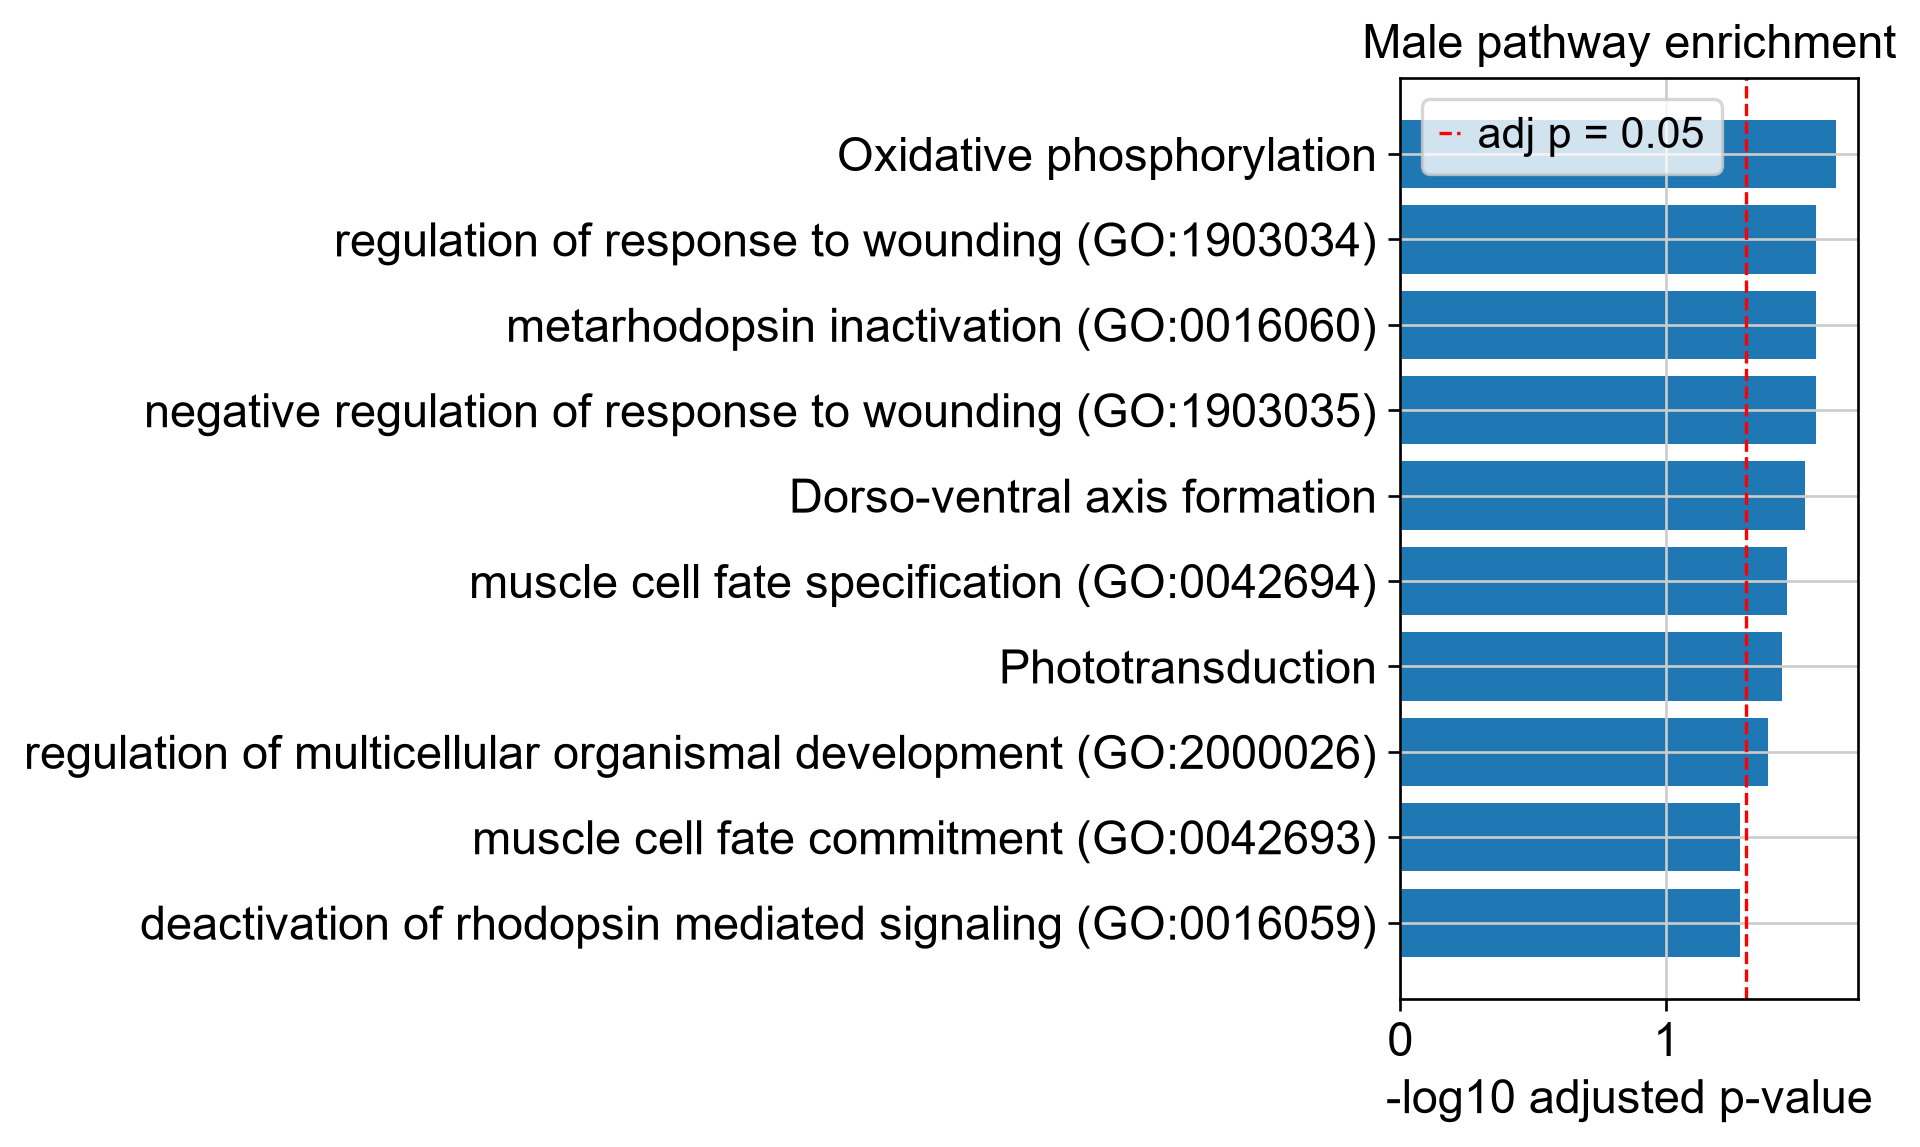

Saved: D:\bmp\sc_project2_drosophila_brain\results\figures\male_pathway_enrichment.png
Female: 0 of top 10 shown terms pass adjusted p < 0.05


C:\Users\Acer\AppData\Local\Temp\ipykernel_12280\2495449020.py:21: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


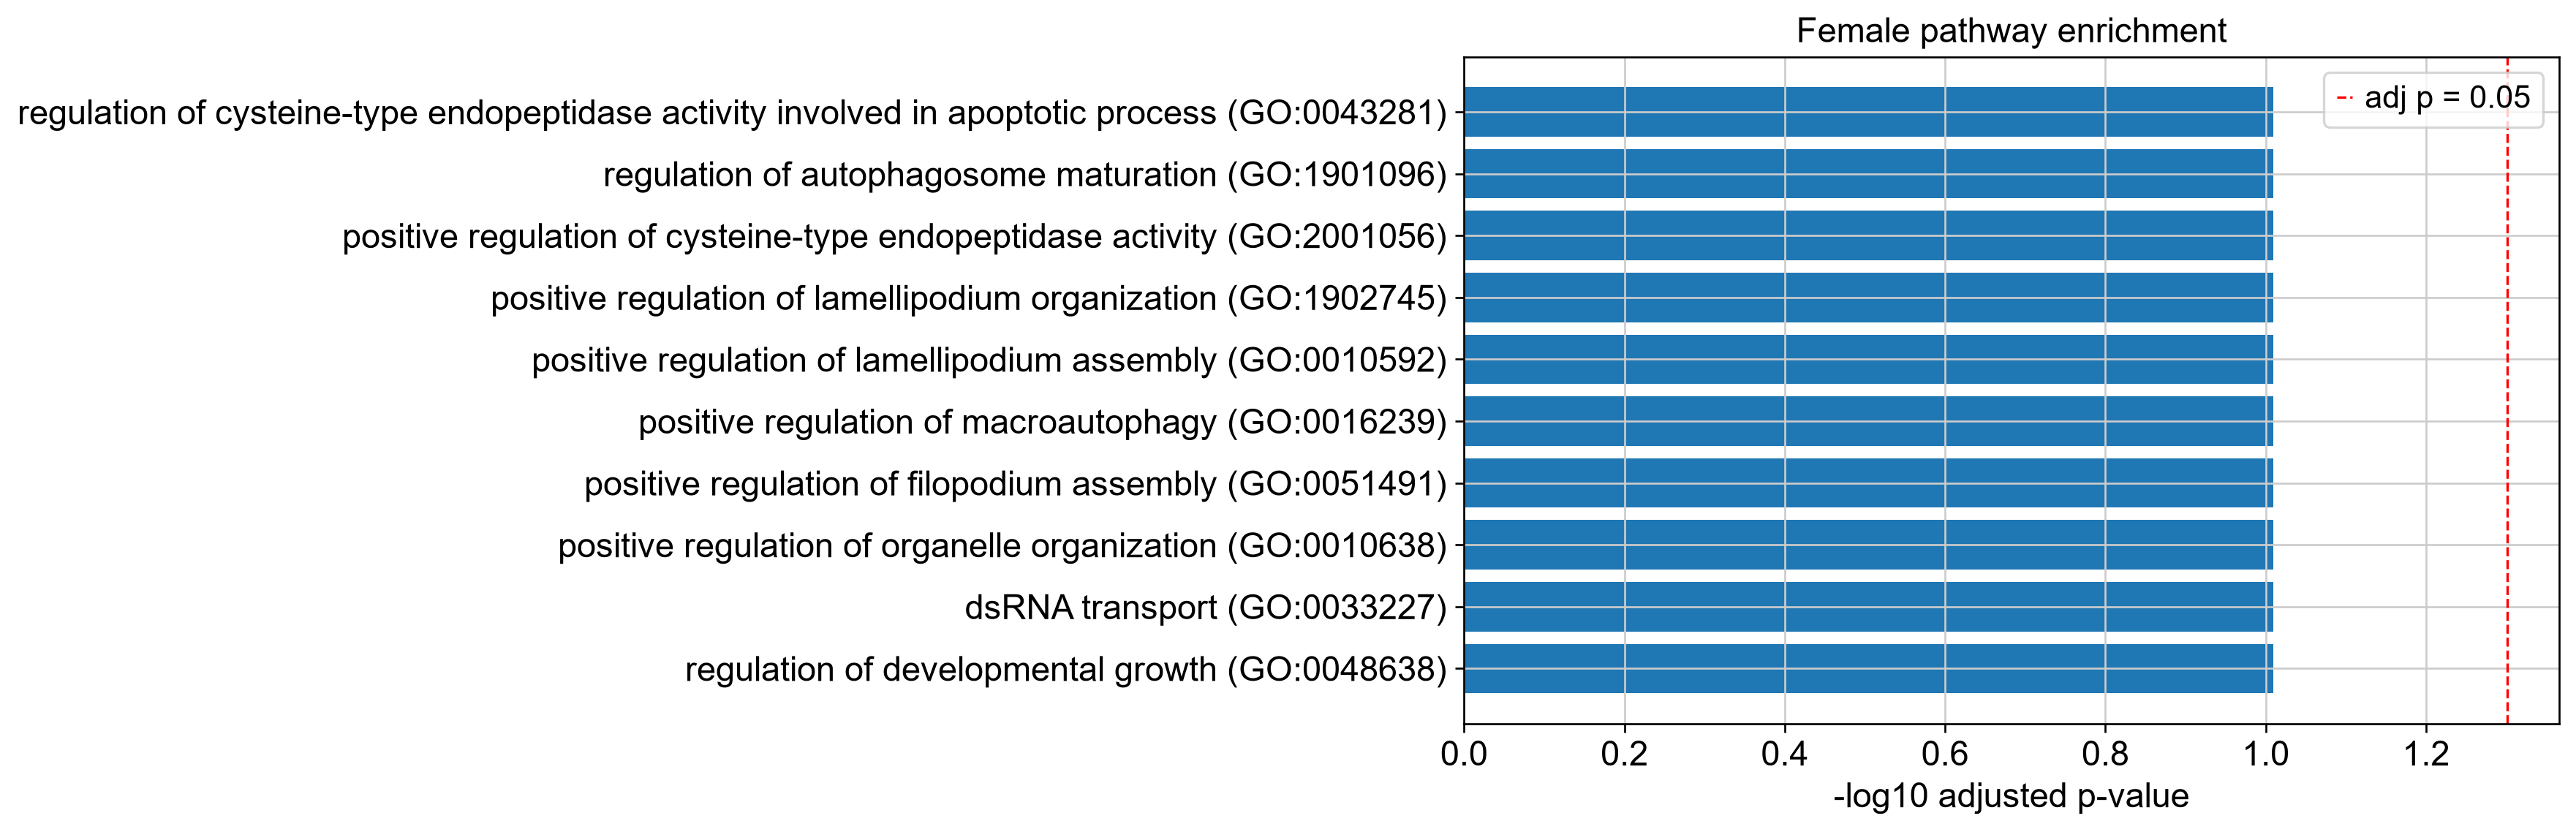

Saved: D:\bmp\sc_project2_drosophila_brain\results\figures\female_pathway_enrichment.png


In [18]:
for sex in ["male", "female"]:
    file = TABLES_DIR / f"{sex}_enrichment_results.csv"
    if not file.exists():
        print(f"No enrichment results file for {sex}, skipping.")
        continue

    df = pd.read_csv(file)
    df = df.dropna(subset=["Term", "Adjusted P-value"])
    df = df[df["Adjusted P-value"] > 0].sort_values("Adjusted P-value").head(10)
    df["neglog10_padj"] = -np.log10(df["Adjusted P-value"])

    n_significant = int((df["Adjusted P-value"] < 0.05).sum())
    print(f"{sex.capitalize()}: {n_significant} of top {len(df)} shown terms pass adjusted p < 0.05")

    plt.figure(figsize=(8, 5))
    plt.barh(df["Term"].iloc[::-1], df["neglog10_padj"].iloc[::-1])
    plt.axvline(-np.log10(0.05), color="red", ls="--", lw=1, label="adj p = 0.05")
    plt.xlabel("-log10 adjusted p-value")
    plt.title(f"{sex.capitalize()} pathway enrichment")
    plt.legend()
    plt.tight_layout()

    output = FIG_DIR / f"{sex}_pathway_enrichment.png"
    plt.savefig(output, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", output)

## Step 16: Final summary and export

In [19]:
summary = pd.DataFrame({
    "metric": ["cells_after_QC_subsampled", "genes_after_QC", "HVGs", "Leiden_clusters",
               "male_significant_DE_genes", "female_significant_DE_genes", "shared_DE_genes"],
    "value": [adata.n_obs, adata.n_vars, int(adata.var["highly_variable"].sum()) if "highly_variable" in adata.var else adata.n_vars,
              adata.obs["leiden_res_0.8"].nunique(), len(male_sig), len(female_sig), len(shared_genes)],
})
display(summary)
summary.to_csv(RESULT_DIR / "final_analysis_summary.csv", index=False)
adata.write_h5ad(RESULT_DIR / "drosophila_cocaine_processed.h5ad")

print("Final AnnData:", RESULT_DIR / "drosophila_cocaine_processed.h5ad")
print("Figures:", FIG_DIR)
print("Results:", RESULT_DIR)
print()
print("REMEMBER for your report: this run used a stratified subsample (~", adata.n_obs,
      "cells) of the 88,923 QC-passed cells due to local memory constraints.")

,metric,value
0,cells_after_QC_subsampled,32000
1,genes_after_QC,2000
2,HVGs,2000
3,Leiden_clusters,23
4,male_significant_DE_genes,70
5,female_significant_DE_genes,156
6,shared_DE_genes,24


Final AnnData: D:\bmp\sc_project2_drosophila_brain\results\drosophila_cocaine_processed.h5ad
Figures: D:\bmp\sc_project2_drosophila_brain\results\figures
Results: D:\bmp\sc_project2_drosophila_brain\results

REMEMBER for your report: this run used a stratified subsample (~ 32000 cells) of the 88,923 QC-passed cells due to local memory constraints.
